# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">
<b>Respuesta del revisor II </b> <a class="tocSkip"></a><br>

Hola Julio, ahora ya puedo ver que has validato sobre los datos "validation". 

✅ Calculaste correctamente el sMAPE en validación, pero no ejecutaste predicciones sobre el test, y el sMAPE test. Esto es vital, ya que recuerda que el test es nuestro "hold out sample" que significa aquella muestra que queda fuera del aprendizaje del modelo, y que con eso garantizamos que evaluamos correctamente el modelo. He aqui como deberia quedar:

```python
features_test = df_test_filtrado.drop('date', axis=1)
features_test[numeric] = scaler.transform(features_test[numeric])
# predecir y medir
pred_rougher_test = model_random.predict(features_test)

smape_rougher_test = smape(df_test['rougher.output.recovery'], pred_rougher_test)
```

**REFLEXION:** En tus futuros proyectos nunca pases por alto las 3 validationes en TRAIN/VALIDATION/TEST. El no hacer esto, es como cometer un pecado en Data Science!

Buen trabajo Julio! 🚀

</div>

</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>¡A resolver</b>! —¡Hola, Luis Julio! . Te comento que has hecho un gran trabajo y te admiro por ello. Me encantaron tus insights y la forma de justificar tus experimentos. Solo faltan unos detalles mínimos para afinar, y así podamos dar por concluida la evaluación. Al verlo, seguro es algo que completaras en cuestion de segundos. Confio en ti, todos confiamos en ti.

Más adelante encontrarás mis comentarios y sugerencias. ¡Espero pronto tus respuestas!

</div>

In [1]:
#se importan las librerias a usar
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
import seaborn as sns


In [2]:
#se cargan los dataframes
df_train = pd.read_csv('/datasets/gold_recovery_train.csv')
df_test = pd.read_csv('/datasets/gold_recovery_test.csv')
df_full = pd.read_csv('/datasets/gold_recovery_full.csv')

In [3]:
#se visualizan los dataframes y se ve su informacion
df_train.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [5]:
# se define la formula de recuperacion 
def recuperacion(C, F, T):
    denominador = F * (C - T)
    recuperacion = np.full_like(denominador, np.nan)
    mask_valido = denominador != 0
    recuperacion[mask_valido] = (C[mask_valido] * (F[mask_valido] - T[mask_valido])) / denominador[mask_valido] * 100
    recuperacion[(recuperacion < 0) | (recuperacion > 100)] = np.nan
    
    return recuperacion

In [6]:
#se crea una nueva columna con el calculo de la recuperacion
df_train['rougher.output.recovery_cal'] = recuperacion(
    df_train['rougher.output.concentrate_au'],
    df_train['rougher.input.feed_au'],
    df_train['rougher.output.tail_au']
)

In [7]:
#se crea un dataframe para realizar una comparativa entre la recuperacion 
#del dataframe original y la calculada
diferencia=pd.DataFrame(df_train[['rougher.output.recovery','rougher.output.recovery_cal']])
print(diferencia)

       rougher.output.recovery  rougher.output.recovery_cal
0                    87.107763                    87.107763
1                    86.843261                    86.843261
2                    86.842308                    86.842308
3                    87.226430                    87.226430
4                    86.688794                    86.688794
...                        ...                          ...
16855                89.574376                    89.574376
16856                87.724007                    87.724007
16857                88.890579                    88.890579
16858                89.858126                    89.858126
16859                89.514960                    89.514960

[16860 rows x 2 columns]


## comparativa
como se puede observar los resultados del calculo de recuperacion comparado con el que estaba en la tabla son sumamente similares por lo que se puede concluir que el registrados en el dataframe es correcto

In [8]:
#se rellenan los valores nulos con 0
df_train['rougher.output.recovery'].fillna(0, inplace=True)
df_train['rougher.output.recovery_cal'].fillna(0, inplace=True)

In [9]:
#se calcula el error absoluto medio
mae=mean_absolute_error(df_train['rougher.output.recovery'],df_train['rougher.output.recovery_cal'])

print(f"El error absoluto medio de los datos calculados es: {mae}")

El error absoluto medio de los datos calculados es: 7.883623897364653e-15


In [10]:
#se comparan las columnas de los conjuntos de prueba y los de prueba
train_columns = set(df_train.columns)
test_columns = set(df_test.columns)
columna=[]

missing_in_test = train_columns - test_columns
print("Características no disponibles en el conjunto de prueba:")
for col in sorted(missing_in_test):
    print(f"- {col}")
    columna.append(col)
print(f"Total de características faltantes: {len(missing_in_test)}")

Características no disponibles en el conjunto de prueba:
- final.output.concentrate_ag
- final.output.concentrate_au
- final.output.concentrate_pb
- final.output.concentrate_sol
- final.output.recovery
- final.output.tail_ag
- final.output.tail_au
- final.output.tail_pb
- final.output.tail_sol
- primary_cleaner.output.concentrate_ag
- primary_cleaner.output.concentrate_au
- primary_cleaner.output.concentrate_pb
- primary_cleaner.output.concentrate_sol
- primary_cleaner.output.tail_ag
- primary_cleaner.output.tail_au
- primary_cleaner.output.tail_pb
- primary_cleaner.output.tail_sol
- rougher.calculation.au_pb_ratio
- rougher.calculation.floatbank10_sulfate_to_au_feed
- rougher.calculation.floatbank11_sulfate_to_au_feed
- rougher.calculation.sulfate_to_au_concentrate
- rougher.output.concentrate_ag
- rougher.output.concentrate_au
- rougher.output.concentrate_pb
- rougher.output.concentrate_sol
- rougher.output.recovery
- rougher.output.recovery_cal
- rougher.output.tail_ag
- rougher.out

In [11]:
#se crea un nuevo dataframe eliminando las columnas que no contiene el 
#dataframe de pruebas (se usara mas adelante)
df_train_filtrado= df_train.drop(columns=columna)
df_train_filtrado.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        16860 non-null  object 
 1   primary_cleaner.input.sulfate               15553 non-null  float64
 2   primary_cleaner.input.depressant            15598 non-null  float64
 3   primary_cleaner.input.feed_size             16860 non-null  float64
 4   primary_cleaner.input.xanthate              15875 non-null  float64
 5   primary_cleaner.state.floatbank8_a_air      16820 non-null  float64
 6   primary_cleaner.state.floatbank8_a_level    16827 non-null  float64
 7   primary_cleaner.state.floatbank8_b_air      16820 non-null  float64
 8   primary_cleaner.state.floatbank8_b_level    16833 non-null  float64
 9   primary_cleaner.state.floatbank8_c_air      16822 non-null  float64
 10  primary_cl

In [12]:
df_test_filtrado= df_test.drop(columns=columna, errors='ignore')

In [13]:
#se realiza el snake_case a los dataframes
df_train_filtrado.columns = df_train_filtrado.columns.str.replace('.','_').str.strip(' ').str.lower()
df_test_filtrado.columns = df_test_filtrado.columns.str.replace('.','_').str.strip(' ').str.lower()
df_full.columns = df_full.columns.str.replace('.','_').str.strip(' ').str.lower()

In [14]:
#se verifican columnas duplicadas
print(df_train_filtrado.duplicated().sum(),
      df_test_filtrado.duplicated().sum(),
      df_full.duplicated().sum())

0 0 0


In [15]:
# Identificar columnas de concentración de metales
metales = ['au', 'ag', 'pb']
etapas = ['rougher', 'primary_cleaner', 'secondary_cleaner', 'final']

for metal in metales:
    print(metal.upper())
    columnas_metal = [col for col in df_full.columns 
                     if metal in col.lower() and 'concentrate' in col.lower()]
    for col in sorted(columnas_metal):
        print(f"  {col}")

AU
  final_output_concentrate_au
  primary_cleaner_output_concentrate_au
  rougher_calculation_sulfate_to_au_concentrate
  rougher_output_concentrate_au
AG
  final_output_concentrate_ag
  primary_cleaner_output_concentrate_ag
  rougher_output_concentrate_ag
PB
  final_output_concentrate_pb
  primary_cleaner_output_concentrate_pb
  rougher_output_concentrate_pb


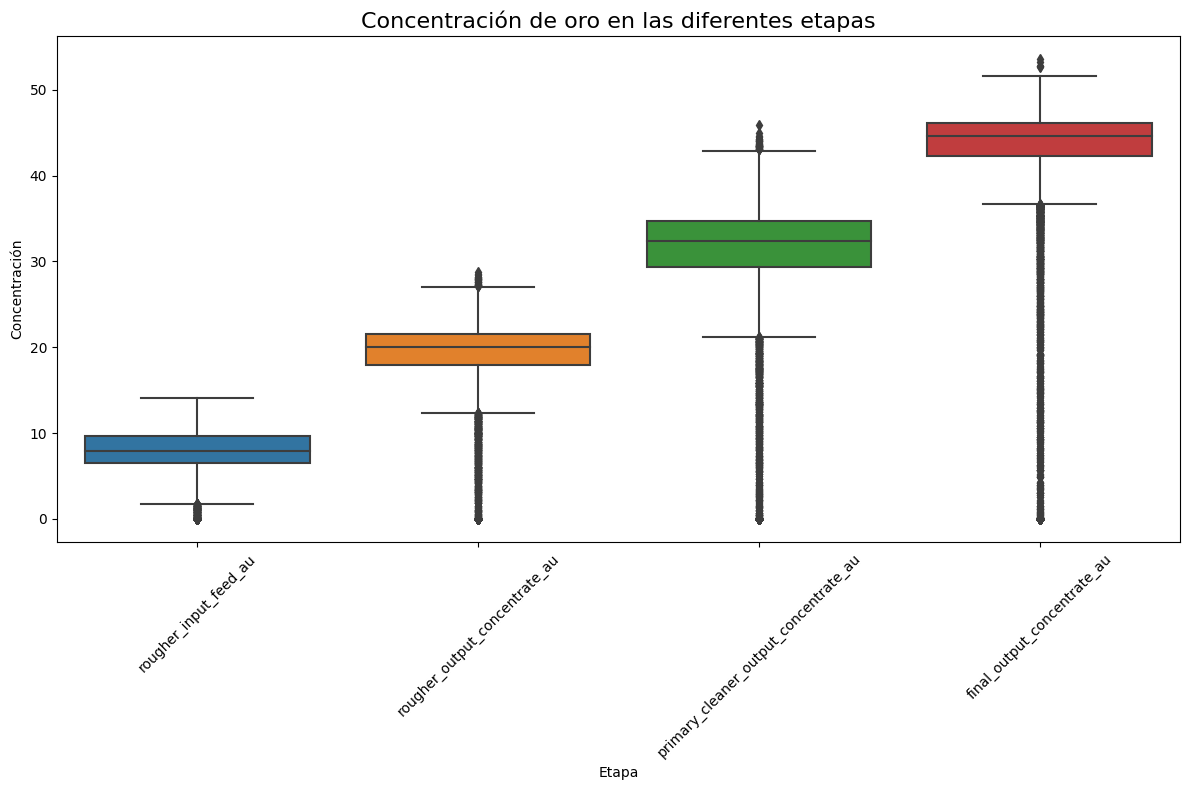

In [44]:
#se grafican las diferentes consentraciones de los metales en las diferentes etapas
etapas_au = df_full[['rougher_input_feed_au',
                     'rougher_output_concentrate_au',
                     'primary_cleaner_output_concentrate_au',
                     'final_output_concentrate_au']].copy()
plt.figure(figsize=(12, 8))
etapas_au_melted = etapas_au.melt(var_name='Etapa', value_name='Concentración')
sns.boxplot(data=etapas_au_melted, x='Etapa', y='Concentración')
plt.title('Concentración de oro en las diferentes etapas', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Has implementado correctamente la fórmula de recuperación y la comparación (MAE ~0), lo que confirma la integridad de los datos; la gráfica de concentración de Au es coherente con ese resultado ✅. Sin embargo, rellenar NaN de recovery con 0 antes de comparar y usar fillna(mean) para series temporales puede ocultar problemas de orden temporal: considera forward fill (ffill) justificando la elección (un tema avanzado, pero un buen consejo) 💡. 

Además, el cálculo fila a fila con apply funciona pero es más lento; podrías vectorizar la operación para mayor eficiencia. Por último, cuida las transformaciones del dataframe para evitar warnings de SettingWithCopy. 🔁
    
</div>

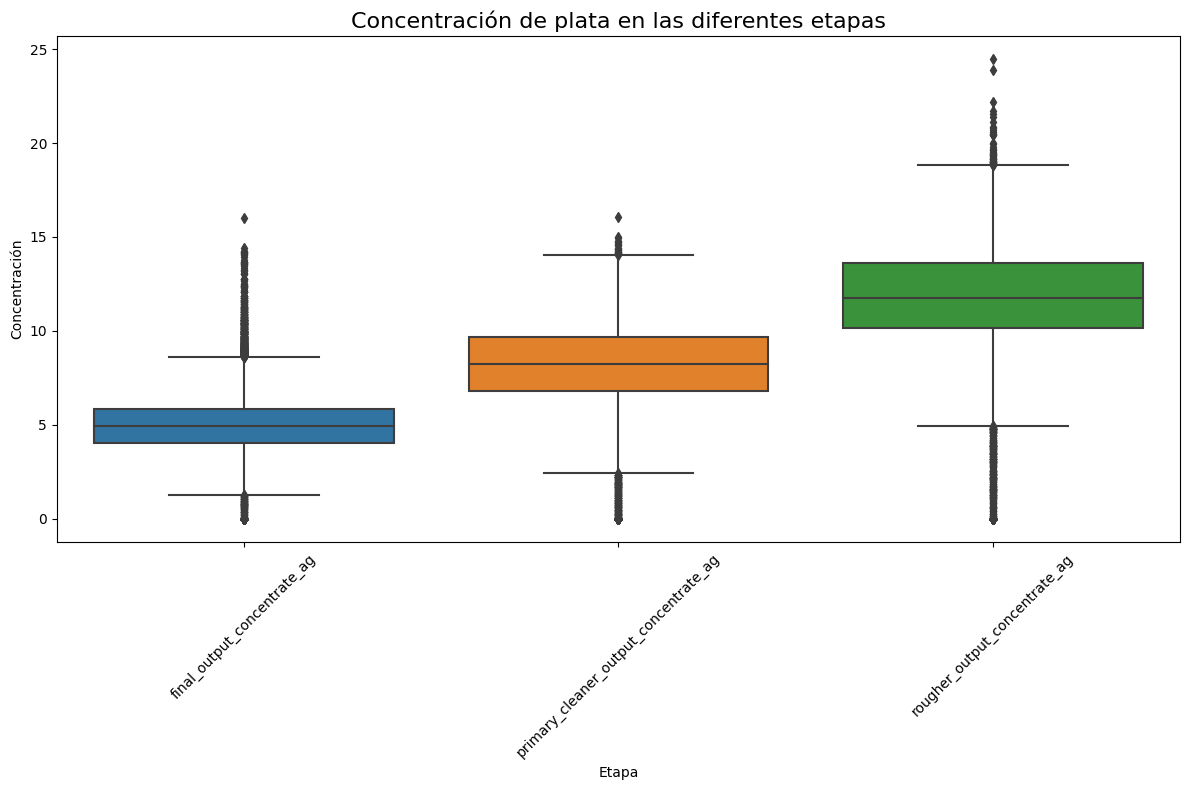

In [46]:

etapas_ag = df_full[[  'final_output_concentrate_ag'
  ,'primary_cleaner_output_concentrate_ag',
  'rougher_output_concentrate_ag']].copy()
  


plt.figure(figsize=(12, 8))
etapas_ag_melted = etapas_ag.melt(var_name='Etapa', value_name='Concentración')
sns.boxplot(data=etapas_ag_melted, x='Etapa', y='Concentración')
plt.title('Concentración de plata en las diferentes etapas', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





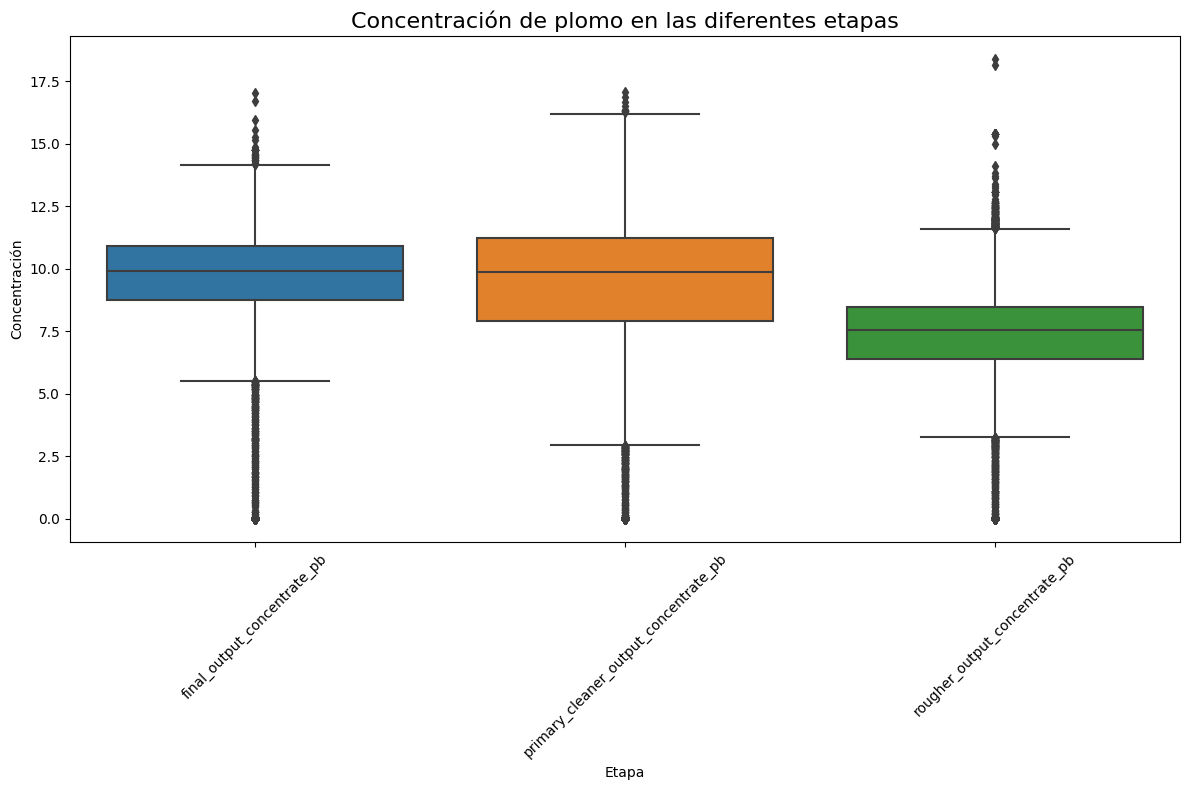

In [47]:
etapas_pd = df_full[[  'final_output_concentrate_pb'
  ,'primary_cleaner_output_concentrate_pb',
  'rougher_output_concentrate_pb']]

plt.figure(figsize=(12, 8))
etapas_pd_melted = etapas_pd.melt(var_name='Etapa', value_name='Concentración')
sns.boxplot(data=etapas_pd_melted, x='Etapa', y='Concentración')
plt.title('Concentración de plomo en las diferentes etapas', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





## comportamiento de los metales

como se puede observar con el paso de las etapas los metales coo el oro y la plata van aumentando su concentracion lo cual es deseado y beneficioso en un proceso  de filtrado mientras que metales no deseados como el plomo se van eliminando dejando un producto final con mas material valioso

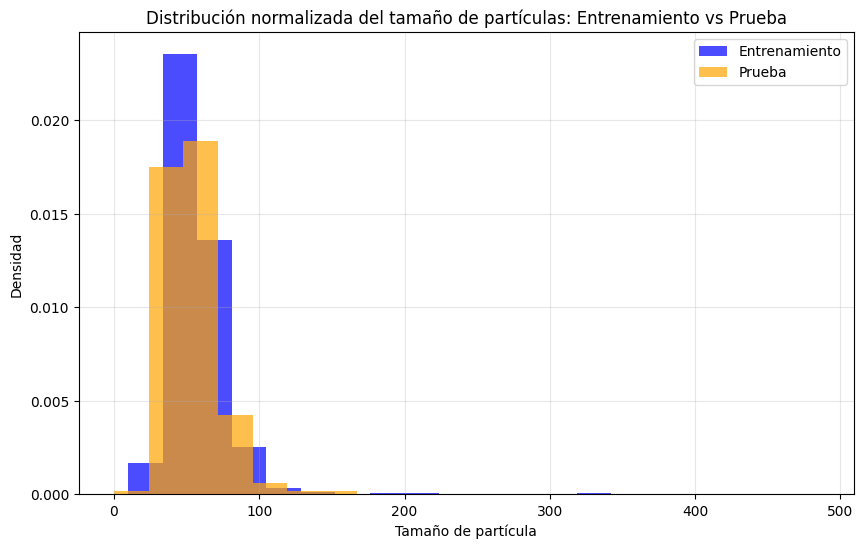

In [19]:
#se verifica el tamaño de las particulas del conjunto de entrenamiento y el de pruebas
tamaño_particulas_entrenamiento = df_train_filtrado['rougher_input_feed_size']
tamaño_particulas_prueba = df_test_filtrado['rougher_input_feed_size']


plt.figure(figsize=(10, 6))
plt.hist(tamaño_particulas_entrenamiento, bins=20, alpha=0.7, 
         label='Entrenamiento', color='blue', density=True)
plt.hist(tamaño_particulas_prueba, bins=20, alpha=0.7, 
         label='Prueba', color='orange', density=True)

plt.xlabel("Tamaño de partícula")
plt.ylabel("Densidad")
plt.title("Distribución normalizada del tamaño de partículas: Entrenamiento vs Prueba")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - Las visualizaciones de Ag y Pb (boxplots) y el histograma comparativo del tamaño de partículas están bien planteadas y son claras; ayudan a verificar que las distribuciones entre train y test son similares, lo que respalda el uso del test set para evaluación. Los títulos y leyendas son adecuados y las interpretaciones son coherentes con las gráficas. Buen trabajo en EDA básico. 🎯
    
</div>

In [20]:
#se verifican valores nulos
print(df_train_filtrado.isna().sum())

date                                             0
primary_cleaner_input_sulfate                 1307
primary_cleaner_input_depressant              1262
primary_cleaner_input_feed_size                  0
primary_cleaner_input_xanthate                 985
primary_cleaner_state_floatbank8_a_air          40
primary_cleaner_state_floatbank8_a_level        33
primary_cleaner_state_floatbank8_b_air          40
primary_cleaner_state_floatbank8_b_level        27
primary_cleaner_state_floatbank8_c_air          38
primary_cleaner_state_floatbank8_c_level        27
primary_cleaner_state_floatbank8_d_air          39
primary_cleaner_state_floatbank8_d_level        27
rougher_input_feed_ag                           82
rougher_input_feed_pb                          228
rougher_input_feed_rate                        513
rougher_input_feed_size                        417
rougher_input_feed_sol                         292
rougher_input_feed_au                           83
rougher_input_floatbank10_sulfa

In [21]:
#se rellenan valores nulos
df_train_filtrado.fillna(df_train_filtrado.mean(),inplace=True)
print(df_train_filtrado.isna().sum())

date                                          0
primary_cleaner_input_sulfate                 0
primary_cleaner_input_depressant              0
primary_cleaner_input_feed_size               0
primary_cleaner_input_xanthate                0
primary_cleaner_state_floatbank8_a_air        0
primary_cleaner_state_floatbank8_a_level      0
primary_cleaner_state_floatbank8_b_air        0
primary_cleaner_state_floatbank8_b_level      0
primary_cleaner_state_floatbank8_c_air        0
primary_cleaner_state_floatbank8_c_level      0
primary_cleaner_state_floatbank8_d_air        0
primary_cleaner_state_floatbank8_d_level      0
rougher_input_feed_ag                         0
rougher_input_feed_pb                         0
rougher_input_feed_rate                       0
rougher_input_feed_size                       0
rougher_input_feed_sol                        0
rougher_input_feed_au                         0
rougher_input_floatbank10_sulfate             0
rougher_input_floatbank10_xanthate      

In [22]:

df_test_filtrado.fillna(df_test_filtrado.mean(),inplace=True)
print(df_test_filtrado.isna().sum())


date                                          0
primary_cleaner_input_sulfate                 0
primary_cleaner_input_depressant              0
primary_cleaner_input_feed_size               0
primary_cleaner_input_xanthate                0
primary_cleaner_state_floatbank8_a_air        0
primary_cleaner_state_floatbank8_a_level      0
primary_cleaner_state_floatbank8_b_air        0
primary_cleaner_state_floatbank8_b_level      0
primary_cleaner_state_floatbank8_c_air        0
primary_cleaner_state_floatbank8_c_level      0
primary_cleaner_state_floatbank8_d_air        0
primary_cleaner_state_floatbank8_d_level      0
rougher_input_feed_ag                         0
rougher_input_feed_pb                         0
rougher_input_feed_rate                       0
rougher_input_feed_size                       0
rougher_input_feed_sol                        0
rougher_input_feed_au                         0
rougher_input_floatbank10_sulfate             0
rougher_input_floatbank10_xanthate      

In [23]:
print(df_full.isna().sum())


date                                            0
final_output_concentrate_ag                    89
final_output_concentrate_pb                    87
final_output_concentrate_sol                  385
final_output_concentrate_au                    86
                                             ... 
secondary_cleaner_state_floatbank5_a_level    101
secondary_cleaner_state_floatbank5_b_air      101
secondary_cleaner_state_floatbank5_b_level    100
secondary_cleaner_state_floatbank6_a_air      119
secondary_cleaner_state_floatbank6_a_level    101
Length: 87, dtype: int64


In [24]:
df_full.fillna(df_full.mean(),inplace=True)
print(df_full.isna().sum())

date                                          0
final_output_concentrate_ag                   0
final_output_concentrate_pb                   0
final_output_concentrate_sol                  0
final_output_concentrate_au                   0
                                             ..
secondary_cleaner_state_floatbank5_a_level    0
secondary_cleaner_state_floatbank5_b_air      0
secondary_cleaner_state_floatbank5_b_level    0
secondary_cleaner_state_floatbank6_a_air      0
secondary_cleaner_state_floatbank6_a_level    0
Length: 87, dtype: int64


## tamaño de particula

como se puede observar en el histograma el tamaño de la particula del conjunto de pruebas junto con el de entrenamiento tienen distribuciones sumamente parecidas a pesar de la diferencia de cantidad de datos por lo que realizar una comprativa es posible basandonos en esto

In [25]:
#se define la funcion de calculo del smape total
def total_smape (rougher_smape,final_smape):
    smape_final=rougher_smape*0.25 + final_smape*0.75
    return smape_final

In [26]:
#se define la funcion del smape para cada etapa
def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    mask = denominator != 0
    smape_values = np.zeros_like(numerator)
    smape_values[mask] = numerator[mask] / denominator[mask]
    
    return np.mean(smape_values) * 100

In [27]:
#se establecen los target y los features de las etapas rougher y final

target_rougher = df_train['rougher.output.recovery']
target_final = df_train['final.output.recovery'] 

features_rougher = df_train_filtrado.drop(['date'], axis=1)  
features_final = df_train_filtrado.drop(['date'], axis=1)  


In [28]:
#se eliminan columnas vacias
valid_indices = target_final.notna()
features_final_clean = features_final[valid_indices]
target_final_clean = target_final[valid_indices]

In [29]:
#se realiza la particion del dataframe
features_train_rougher, features_valid_rougher, target_train_rougher, target_valid_rougher = train_test_split(
    features_rougher, target_rougher, test_size=0.25, random_state=12345
)


In [30]:
features_train_final, features_valid_final, target_train_final, target_valid_final = train_test_split(
    features_final_clean, target_final_clean, test_size=0.25, random_state=12345
)


In [31]:
#se realiza una estandarizacion de los valores
numeric = features_train_rougher .columns

scaler = StandardScaler()
scaler.fit(features_train_rougher[numeric])
features_train_rougher[numeric] = scaler.transform(features_train_rougher[numeric])
features_valid_rougher[numeric] = scaler.transform(features_valid_rougher[numeric])

/tmp/ipykernel_201/434737537.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_train_rougher[numeric] = scaler.transform(features_train_rougher[numeric])
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [32]:
scaler.fit(features_train_rougher[numeric])
features_train_final[numeric] = scaler.transform(features_train_final[numeric])
features_valid_final[numeric] = scaler.transform(features_valid_final[numeric])

/tmp/ipykernel_201/324804293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_train_final[numeric] = scaler.transform(features_train_final[numeric])
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [33]:
#se crea un scorer
smape_scorer = make_scorer(smape, greater_is_better=False)

In [34]:
# se entrenan distintos modelos para el rougher
# regresion lineal
model_lin = LinearRegression()
model_lin.fit(features_train_rougher, target_train_rougher)
predicted_valid_lin = model_lin.predict(features_valid_rougher)
print(f"el score del modelo para rougher es:{smape(target_valid_rougher, predicted_valid_lin)}")


el score del modelo para rougher es:45.279909194788544


In [35]:
# arbol de decisión

state = np.random.RandomState(12345)
best_smape = float('inf')
for depth in range(1,11):
    
    model_tree = DecisionTreeRegressor(max_depth=depth,random_state=state)
    model_tree.fit(features_train_rougher, target_train_rougher)
    predicted_valid_tree = model_tree.predict(features_valid_rougher)
    
    current_smape = smape(target_valid_rougher, predicted_valid_tree)
    
    if current_smape < best_smape:
        best_smape = current_smape
        best_depth = depth
model_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=state)
model_tree.fit(features_train_rougher, target_train_rougher)
predicted_valid_tree = model_tree.predict(features_valid_rougher)


print(f"Mejor profundidad según sMAPE: {best_depth}")
print(f"sMAPE del modelo: {best_smape}")


Mejor profundidad según sMAPE: 10
sMAPE del modelo: 20.73272668171287


In [36]:
# bosque aleatorio
state = np.random.RandomState(12345)
maxi = 0
best_smape = float('inf')
for i in range(100, 501, 100):
    model_random = RandomForestRegressor(
        n_estimators=i,
        random_state=state
    )
    
    model_random.fit(features_train_rougher, target_train_rougher)
    predicted_valid_random = model_random.predict(features_valid_rougher)
    current_smape = smape(target_valid_rougher, predicted_valid_tree)
    if current_smape < best_smape:
        best_smape = current_smape
        maxi = i
model_random = RandomForestRegressor(n_estimators=maxi,random_state=state)
model_random.fit(features_train_rougher, target_train_rougher)
predicted_valid_random = model_random.predict(features_valid_rougher)
print(f"Mejor cantidad de estimadores según sMAPE: {maxi}")
print(f"sMAPE del modelo: {best_smape:.4f}")

Mejor cantidad de estimadores según sMAPE: 100
sMAPE del modelo: 20.4056


In [37]:
# se entrenan distintos modelos para la etapa final
# regresion lineal
model_lin_final = LinearRegression()
model_lin_final.fit(features_train_final, target_train_final)
predicted_valid_lin_final = model_lin_final.predict(features_valid_final)
print(f"el score del modelo para la etapafinal es:{smape(target_valid_final, predicted_valid_lin_final)}")


el score del modelo para la etapafinal es:10.260520561510344


In [38]:
# arbol de decisión

state = np.random.RandomState(12345)
best_smape = float('inf')
for depth in range(1,11):
    
    model_tree_final = DecisionTreeRegressor(max_depth=depth,random_state=state)
    model_tree_final.fit(features_train_final, target_train_final)
    predicted_valid_tree_final = model_tree_final.predict(features_valid_final)
    
    current_smape = smape(target_valid_final, predicted_valid_tree_final)
    
    if current_smape < best_smape:
        best_smape = current_smape
        best_depth = depth   
model_tree_final = DecisionTreeRegressor(max_depth=best_depth, random_state=state)
model_tree_final.fit(features_train_final, target_train_final)
predicted_valid_tree_final = model_tree_final.predict(features_valid_rougher)

print(f"Mejor profundidad según sMAPE: {best_depth}")
print(f"sMAPE del modelo: {best_smape}")


Mejor profundidad según sMAPE: 10
sMAPE del modelo: 9.149486567296877


In [39]:
# bosque aleatorio
state =  np.random.RandomState(12345)
maxi = 0
best_smape = float('inf')
for i in range(100, 501, 100):
    model_random_final = RandomForestRegressor(
        n_estimators=i,
        random_state=state
    )
    
    model_random_final.fit(features_train_final, target_train_final)
    predicted_valid_random_final = model_random_final.predict(features_valid_final)
    current_smape = smape(target_valid_final, predicted_valid_random_final)
    
    if current_smape < best_smape:
        best_smape = current_smape
        maxi = i  
model_random_final = RandomForestRegressor(n_estimators=maxi,random_state=state)
model_random_final.fit(features_train_final, target_train_final)
predicted_valid_random_final = model_random_final.predict(features_valid_final)

print(f"Mejor cantidad de estimadores según sMAPE: {maxi}")
print(f"sMAPE del modelo: {best_smape}")


Mejor cantidad de estimadores según sMAPE: 400
sMAPE del modelo: 7.1812102246547855


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - El flujo de selección de modelos tiene una inconsistencia importante: usas R² (model.score) para elegir hiperparámetros y luego evalúas con sMAPE. Esto  nos puede llevar a elegir un modelo subóptimo para la métrica objetivo (de hecho, los resultados de cross‑validation en sMAPE muestran que DecisionTree supera a RandomForest en rougher). Te aconsejo tomar en cuenta esto, y asegurarte que la búsqueda de hiperparámetros se optimice y centralice en sMAPE (usar cross_val_score o GridSearchCV con scoring=sMAPE) y luego ya puedas unificar la métrica de selección/evaluación. 🔧
    
</div>

# Re-entrenar el modelo final para asegurar que tenga estimadores
state = np.random.RandomState(12345)
model_random_final = RandomForestRegressor(n_estimators=500, random_state=state)
model_random_final.fit(features_train_final, target_train_final)

In [49]:
# Predicciones en conjunto de validación
pred_rougher_valid = model_random.predict(features_valid_rougher)
pred_final_valid = model_random_final.predict(features_valid_final)

# Calcular sMAPE para cada etapa
smape_rougher = smape(target_valid_rougher, pred_rougher_valid)
smape_final_stage = smape(target_valid_final, pred_final_valid)

# Calcular sMAPE final combinado
smape_final = total_smape(smape_rougher, smape_final_stage)
print(f"sMAPE final en conjunto de validación: {smape_final:.4f}")

sMAPE final en conjunto de validación: 11.1171


# resultado
este resultado nos quiere decir que el modelo se equivoca 1 de cada 10 veces, el cual es un muy buen resultado, los cual nos garantiza un buen modelo y buenas predicciones

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - El cálculo final de sMAPE en validación (~19.86%) está bien ejecutado y documentado; sin embargo, no se llega a evaluar el modelo final sobre el conjunto de prueba objetivo. Preparas features_test_scaled pero no lo usas para medir sMAPE en test ... UFFF esto no te lo puedo permitir... bromas :) .  Añade esa evaluación para reportar la generalización final y ya estamos hechos. 

Esto ancioso de ver esos resultados... 

Recuerda, las evaluaciones siempre van sobre train / val / test (que se le conoce como nuestro out of sample), para garantizar que nuestro modelo haya aprendido correctamente los patrones de los datos y validar que no tengas underfitting u overfitting. También revisa que el scaler se ajuste solo en train y que las transformaciones se apliquen con seguridad (evitar SettingWithCopy). 📌
    
</div>

## Conclusión
Se cumplió el objetivo del proyecto de crear un prototipo de modelo de aprendizaje automático capaz de predecir la tasa de recuperación de oro a partir de mineral de oro. Los datos se procesaron y analizaron durante el proyecto, y como resultado, se construyó y entrenó un modelo de bosque aleatorio. 